# Week 1: Data Acquisition, Cleaning & Feature Engineering

# Import Libraries 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [ ]:
df = pd.read_csv("hotel_bookings.csv")

df.head()

# Check structure and missing values

In [2]:
df.shape

(119390, 32)

In [3]:
df.columns


Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [9]:
df.isnull().sum()


hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [5]:
df.describe()


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [17]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

# Finding Duplicates

In [45]:
df.duplicated().sum()

np.int64(31994)

In [16]:

df.loc[:, 'children'] = df['children'].fillna(0)
df.loc[:, 'agent'] = df['agent'].fillna(0)
df.loc[:, 'company'] = df['company'].fillna(0)
df.loc[:, 'country'] = df['country'].fillna('Unknown')

# Remove Duplicates

In [46]:
df.drop_duplicates(inplace=True)

In [21]:
df.duplicated().sum()

np.int64(0)

# Handle Outliers (ADR)
# ADR = Average Daily Rate.

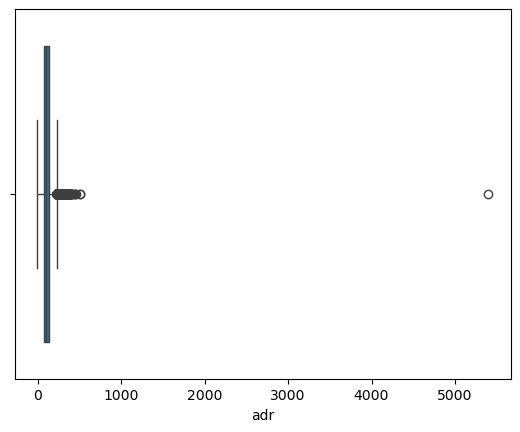

In [47]:
sns.boxplot(x=df['adr'])
plt.show()

# Remove extreme values.

In [26]:
df = df[df['adr'] < 500]

# Total Stay

In [27]:
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Total Guest

In [29]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# Convert Date Column

In [30]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

# Save Cleaned Dataset

In [31]:
df.to_csv("cleaned_hotel_booking.csv", index=False)

# Week 2: Exploratory Data Analysis (EDA)

# Cancellation Distribution

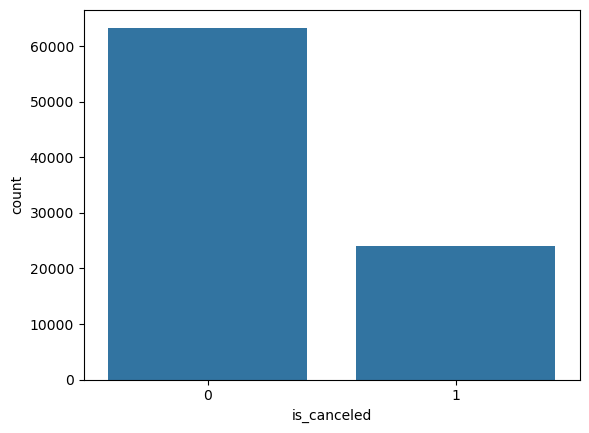

In [32]:
sns.countplot(x='is_canceled', data=df)
plt.show()

# Hotel Type vs Cancellation

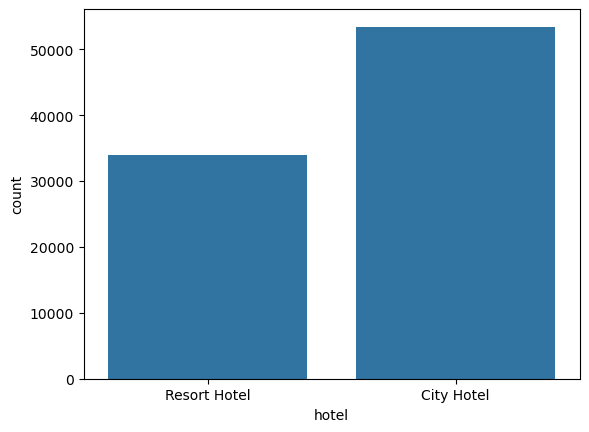

In [55]:
sns.countplot(x='hotel', data=df)
plt.show()

# Lead Time vs Cancellation

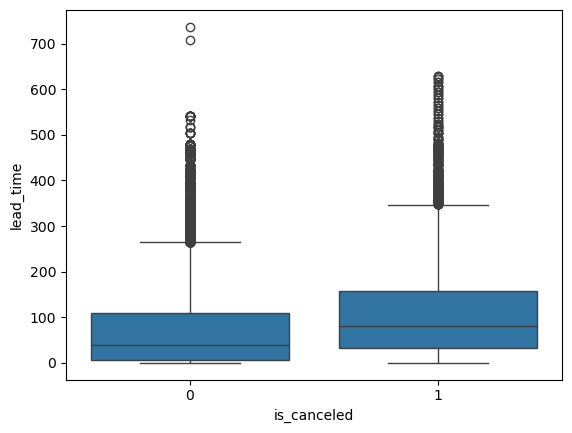

In [48]:
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.show()

# Booking Trends by Month

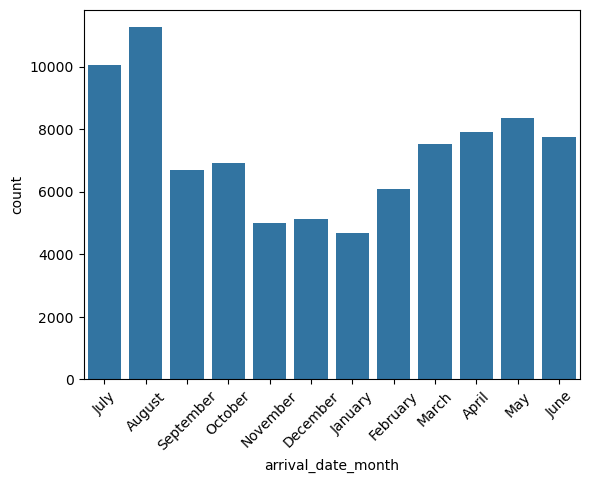

In [49]:
sns.countplot(x='arrival_date_month', data=df)
plt.xticks(rotation=45)
plt.show()

# Market Segment Analysis

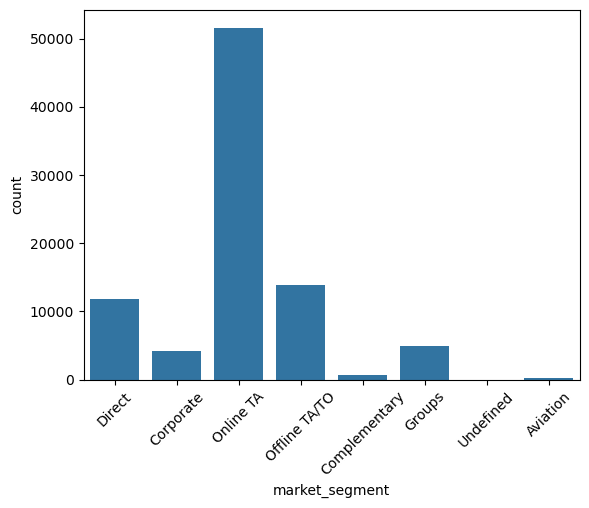

In [50]:
sns.countplot(x='market_segment', data=df)
plt.xticks(rotation=45)
plt.show()

# ADR Distribution

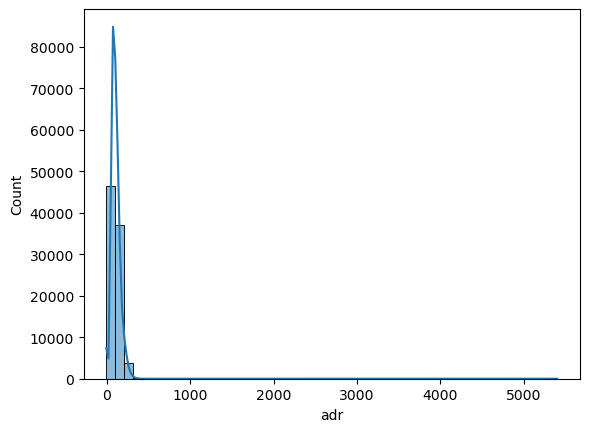

In [52]:
sns.histplot(df['adr'], bins=50, kde=True)
plt.show()

# Correlation Matrix


In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.show()

# WEEK 3: Churn Prediction (Cancellation Prediction Model)


In [14]:
Will a booking be canceled or not?

Target column usually:

is_canceled (0 = No, 1 = Yes)

SyntaxError: invalid syntax (2882141396.py, line 3)

# Prepare Data for Modeling
1. Select features (important columns)

In [15]:
features = [
    'lead_time',
    'adr',
    'total_stay',
    'deposit_type',
    'customer_type',
    'market_segment'
]

# 2. Convert categorical → numeric

In [16]:
import pandas as pd
import numpy as np
df = pd.read_csv("hotel_bookings.csv")
df.head()
df = pd.get_dummies(df, drop_first=True)

# 3.Train-Test Split
Define X and Y

In [17]:
X = df.drop('is_canceled', axis=1)  # Features
y = df['is_canceled']              # Target

# 4.Split the data

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5.Build Your First Model (Logistic Regression)

In [22]:
# Step 1: Handle missing values FIRST
X = X.fillna(X.mean())

# If still categorical columns (rare after get_dummies)
X = X.fillna(0)   # safer than "Unknown" for ML

# Step 2: NOW split again
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Model Evaluation

In [25]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14907
           1       1.00      1.00      1.00      8971

    accuracy                           1.00     23878
   macro avg       1.00      1.00      1.00     23878
weighted avg       1.00      1.00      1.00     23878

ROC-AUC: 1.0


# Confusion Matrix

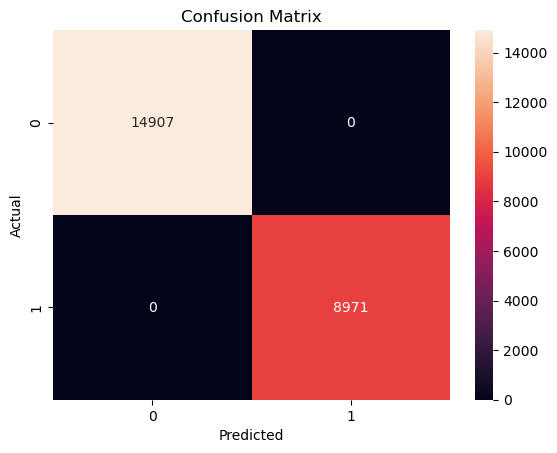

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Feature Importance

In [12]:
importance = model.coef_[0]

import pandas as pd

feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feature_imp.head(10)

,Feature,Importance
242,deposit_type_Non Refund,2.933694
169,country_PRT,1.983229
245,customer_type_Transient,1.104568
214,market_segment_Groups,0.944954
248,reservation_status_No-Show,0.601488
220,distribution_channel_TA/TO,0.395851
216,market_segment_Online TA,0.271116
115,country_ITA,0.219567
4,stays_in_weekend_nights,0.211773
21,arrival_date_month_December,0.200301




# 🔹 Key Findings:

High lead_time → higher cancellations

No deposit bookings → high risk

Certain market segments → frequent cancellations

ADR impacts booking decisions

# Business Recommendations
🔹 Retention Strategy

Offer discounts for high-risk customers

Send reminders before check-in

🔹 Pricing Strategy

Increase prices during peak demand

Reduce prices during low demand

🔹 Policy Changes

Introduce partial deposit

Add cancellation charges

In [29]:
df.to_csv("cleaned_hotel_data.csv", index=False)